In [1]:
import sys
import numpy as np
import pandas as pd

import scipy.stats
from scipy.signal import argrelmin
from scipy.optimize import curve_fit
import scipy.stats as st

import numpy.ma as ma
import glob

import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import xarray as xr

In [ ]:

def prep_ts(ts_data, time_data):
    doy = [x for x in time_data]  
    ts_use = pd.Series(ts_data, index=doy)
    return ts_use


def calc_ar1(x):
    return ma.corrcoef(ma.masked_invalid(x[:-1]), ma.masked_invalid(x[1:]))[0,1]

def compute_lam(x, dt=1):
    dx = (x[1:] - x[:-1]) / dt
    x0 = x[:-1]
    mask = ~np.isnan(x0) & ~np.isnan(dx)
    return st.linregress(x0[mask], dx[mask])[0]

def compute_sigma(x, dt=1):
    dx = (x[1:] - x[:-1]) / dt
    lamb = compute_lam(x, dt)
    diff = dx - lamb * x[:-1]
    return np.nanstd(diff) * np.sqrt(dt)


def harmonic_fit(ser, order=3):
    import statsmodels.api as sm
    harm_freq = list(range(1, order+1))
    
    x, y = ser.index, ser.values
    
    # x = x / 365.25
    # x_rad = x * 2 * np.pi #Convert days to radians for harmonic fitting

    x = np.array([(xi - pd.Timestamp('1970-01-01')).days for xi in x]) / 365.25
    x_rad = x * 2 * np.pi #Convert days to radians for harmonic fitting
    
    #Create empty array to hold the independents
    nr_indep = order*2 + 2
    indep = np.empty((y.shape[0], nr_indep))
    
    #Add constant for intercept and then time
    indep[:,0] = 1
    indep[:,1] = x_rad
    
    #Now create the harmonic variables
    i = 2
    for freq in harm_freq:
        cos = np.cos(x_rad * freq)
        sin = np.sin(x_rad * freq)
        indep[:,i] = cos
        i = i + 1
        indep[:,i] = sin
        i = i + 1
        
    model = sm.OLS(y, indep, missing='drop').fit()
    coefs = model.params
    fitted = []
    for t in range(x_rad.shape[0]):
        data = indep[t,:]
        harm_term = np.nansum(coefs*data)
        fitted.append(harm_term)
    fitted = np.array(fitted)
    return pd.Series(ser.values - fitted, index=ser.index)


def runmean(x, w):
    n = x.shape[0]
    xs = np.zeros_like(x)
    for i in range(w // 2):
        xs[i] = np.nanmean(x[: i + w // 2 + 1])
    for i in range(n - w // 2, n):
        xs[i] = np.nanmean(x[i - w // 2 + 1:])
    for i in range(w // 2, n - w // 2):
        xs[i] = np.nanmean(x[i - w // 2 : i + w // 2 + 1])
    return x - xs


def deseason_detrend(ser, yrs=5, yl=24):
    rm_offline = pd.Series(runmean(ser.values, yrs*yl), index=ser.index)
    deseason_rolling = harmonic_fit(rm_offline, order=3)
    return deseason_rolling

def resilience_calc(res_ts):
    lambda_var, lambda_ac1= np.nan, np.nan

    try:
        if calc_ar1(res_ts.values) < 0:
            lambda_ac1 = -999
        else:
            lambda_ac1 = np.log(calc_ar1(res_ts.values))    
        var = np.nanvar(res_ts.values)
        sigma = compute_sigma(res_ts.values)
        if sigma**2/var > 1:
            lambda_var = -999
        else:
            lambda_var = 0.5 * np.log(1-sigma**2 / var)
    except Exception as e:
        print('null')
    
    return lambda_var, lambda_ac1



In [ ]:
fp1 = r'I:/Ku-band/result/'
op = r'I:/Ku-band/resilience/'
dy = []
for year in range(1988, 2018):
    print('{}year'.format(year))
    files = glob.glob(fp1 + 'vod_{}'.format(year) + '.nc')
    files.sort()
    for file in files:
        da = xr.open_dataset(file)    
        dy.append(da)

vodY = xr.concat(dy, dim='time').sel(time=slice('1988-01-01', '2017-12-31'))   # lat=slice(50, 30), lon=slice(110, 116)
vod_point = vodY.sel(lat = 28, lon = 101, method = 'nearest')

正在处理1988年
正在处理1989年
正在处理1990年
正在处理1991年
正在处理1992年
正在处理1993年
正在处理1994年
正在处理1995年
正在处理1996年
正在处理1997年
正在处理1998年
正在处理1999年
正在处理2000年
正在处理2001年
正在处理2002年
正在处理2003年
正在处理2004年
正在处理2005年
正在处理2006年
正在处理2007年
正在处理2008年
正在处理2009年
正在处理2010年
正在处理2011年
正在处理2012年
正在处理2013年
正在处理2014年
正在处理2015年
正在处理2016年
正在处理2017年


In [11]:
vodY

<xarray.Dataset>
Dimensions:          (time: 720, lon: 1440, lat: 720)
Coordinates:
  * time             (time) datetime64[ns] 1988-01-08 1988-01-23 ... 2017-12-23
  * lon              (lon) float64 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * lat              (lat) float64 89.88 89.62 89.38 ... -89.38 -89.62 -89.88
Data variables:
    vod              (time, lat, lon) float64 nan nan nan nan ... nan nan nan
    sensor_flag      (time, lat, lon) float64 nan nan nan nan ... nan nan nan
    processing_flag  (time, lat, lon) float64 nan nan nan nan ... nan nan nan

In [ ]:

def spatial_resilience(ts):
    if np.isnan(ts).all() :
        resilience = (np.nan, np.nan)
    else:
        ser = prep_ts(ts, vod_point.time.values)
        res = deseason_detrend(ser, yrs=5, yl=24)
        resilience = resilience_calc(res)
    return resilience

In [19]:
landCover = xr.open_dataset(r'E:/runoff/global_vegetation_resilience/landcover_vod_mask1.nc').modis_landcover
ld= landCover.where(np.isnan(landCover), 1)
# ld1 = ld.where(ld < 0, 1)

ld

<xarray.DataArray 'modis_landcover' (lat: 720, lon: 1440)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 89.88 89.62 89.38 89.12 ... -89.38 -89.62 -89.88
  * lon      (lon) float64 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9

In [20]:
vods = vodY.vod * ld.values


In [21]:
resilience_result =  xr.apply_ufunc(
    spatial_resilience,
    vods,
    input_core_dims=[['time']],
    output_core_dims=[[],[]],
    vectorize= True
)

像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空置
像元为空

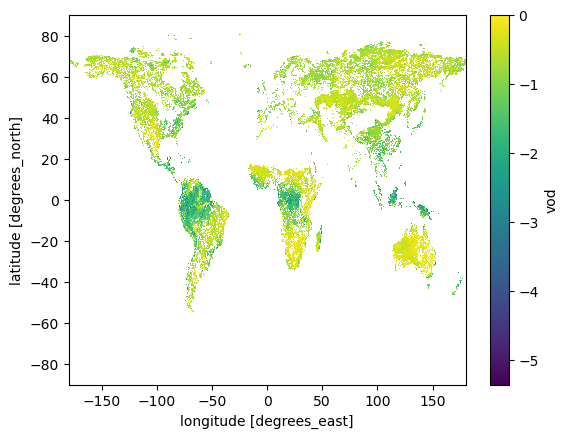

In [22]:
var, ac1 = resilience_result
var.where(var >-10).plot()

In [24]:
var

<xarray.DataArray 'vod' (lat: 720, lon: 1440)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lon      (lon) float64 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * lat      (lat) float64 89.88 89.62 89.38 89.12 ... -89.38 -89.62 -89.88

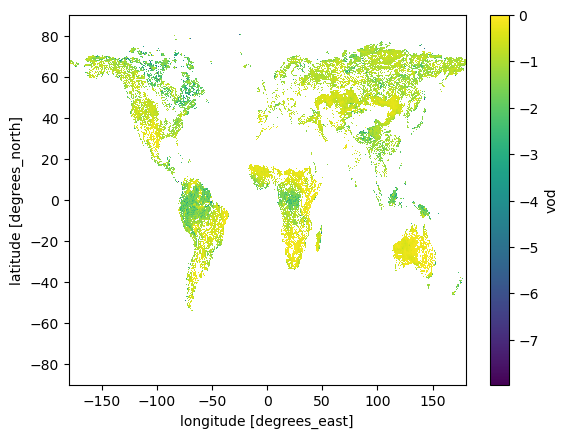

In [27]:
ac2 = ac1.where(ac1 > -8)
ac2.where(ac2 <=0).plot()

In [26]:
# var.to_netcdf(op + 'vod_var_relicience_1988_2017.nc')
ac1.to_netcdf(op + 'vod_ac1_relicience_1988_2017.nc')